# Information Visualization I 
## School of Information, University of Michigan

## Week 3: 
- Perception / Cognition

## Assignment Overview
### This assignment's objectives include:

- Review, refect, and apply the concepts of the perception pipeline. Justify how different encodings impact the effectiveness of a visualization depending on the human perception process.

!["Drawing"](/voc/data/preattentive_resized.png)

<p style="text-align: center;"> Preattentive Processing </p>

- Recreate visualizations and propose new and alternative visualizations using [Altair](https://altair-viz.github.io/) 

### The total score of this assignment will be 100 points consisting of:
- Case study reflection: America's Favorite 'Star Wars' Movies (And Least Favorite Characters) (25 points)
- Altair programming exercise (75 points)

### Resources:
- Article by [FiveThirtyEight](https://fivethirtyeight.com) available  [online](https://fivethirtyeight.com/features/americas-favorite-star-wars-movies-and-least-favorite-characters/) (Hickey, 2014)  
- Datasets from FiveThirtyEight, we have downloaded a subset of this data in the folder [./assets](assets)
    - The original dataset can be found at [FiveThirtyEight Star Wars Survey](https://github.com/fivethirtyeight/data/tree/master/star-wars-survey)
    

### Important notes:
1) There will be a couple of places where the numbers you get when you select rows may be a little different than 538, but the percents should still work (e.g., 828 instead of 834). You'll see this in our examples. If you can somehow get the data to match exactly, that's great too.

2) A lot of this assignment will be based on building "compound" charts. Using the wrong strategy will mean that you are spending a lot of time "cleaning up" charts. We strongly suggest reading through (and understanding) the Altair documentation [on this](https://altair-viz.github.io/user_guide/compound_charts.html).

3) Grading for this assignment is entirely done by a human grader. They will be running tests on the functions we ask you to create. This means there is no autograding (submitting through the autograder will result in an error). You are expected to test and validate your own code. 

4) Keep your notebooks clean and readable. If your code is highly messy or inefficient you will get a deduction.

5) Follow the instructions for submission on Coursera. You will be providing us a generated link to a read-only version of your notebook and a PDF. When turning in your PDF, please use the File -> Print -> Save as PDF option ***from your browser***. Do ***not*** use the File->Download as->PDF option. Complete instructions for this are under Resources in the Coursera page for this class. If you're having trouble with printing, take a look at [this video](https://youtu.be/PiO-K7AoWjk).

In [1]:
import os
import urllib.request

# Create the assets folder if it doesn't exist
os.makedirs('./assets', exist_ok=True)

# Download the Star Wars dataset
url = 'https://raw.githubusercontent.com/fivethirtyeight/data/master/star-wars-survey/StarWars.csv'
file_path = './assets/StarWars.csv'

urllib.request.urlretrieve(url, file_path)
print(f"Downloaded data to {file_path}")

Downloaded data to ./assets/StarWars.csv


In [6]:
# Let's look at the actual data in row 1 to understand what the "Unnamed" columns contain
print("Sample data from first actual respondent (row 1):")
print(df.iloc[0])

Sample data from first actual respondent (row 1):
RespondentID                                                                                                                                                                     3292879998.0
Have you seen any of the 6 films in the Star Wars franchise?                                                                                                                              Yes
Do you consider yourself to be a fan of the Star Wars film franchise?                                                                                                                     Yes
Which of the following Star Wars films have you seen? Please select all that apply.                                                                  Star Wars: Episode I  The Phantom Menace
Unnamed: 4                                                                                                                                        Star Wars: Episode II  Attack of the Clones


In [7]:
# Create better column names
new_column_names = [
    'RespondentID',
    'seen_any',
    'fan',
    'seen_1',  # Phantom Menace
    'seen_2',  # Attack of Clones
    'seen_3',  # Revenge of Sith
    'seen_4',  # A New Hope
    'seen_5',  # Empire Strikes Back
    'seen_6',  # Return of Jedi
    'rank_1',  # Ranking for Episode I
    'rank_2',  # Ranking for Episode II
    'rank_3',  # Ranking for Episode III
    'rank_4',  # Ranking for Episode IV
    'rank_5',  # Ranking for Episode V
    'rank_6',  # Ranking for Episode VI
    'char_han',
    'char_luke',
    'char_leia',
    'char_anakin',
    'char_obiwan',
    'char_palpatine',
    'char_vader',
    'char_lando',
    'char_boba',
    'char_c3po',
    'char_r2d2',
    'char_jarjar',
    'char_padme',
    'char_yoda',
    'shot_first',
    'expanded_universe_fan',
    'expanded_universe',
    'star_trek_fan',
    'gender',
    'age',
    'income',
    'education',
    'location'
]

# Assign new column names
df.columns = new_column_names

# Verify
print("New column names:")
print(df.columns.tolist())
print("\nFirst few rows with new names:")
df.head()

New column names:
['RespondentID', 'seen_any', 'fan', 'seen_1', 'seen_2', 'seen_3', 'seen_4', 'seen_5', 'seen_6', 'rank_1', 'rank_2', 'rank_3', 'rank_4', 'rank_5', 'rank_6', 'char_han', 'char_luke', 'char_leia', 'char_anakin', 'char_obiwan', 'char_palpatine', 'char_vader', 'char_lando', 'char_boba', 'char_c3po', 'char_r2d2', 'char_jarjar', 'char_padme', 'char_yoda', 'shot_first', 'expanded_universe_fan', 'expanded_universe', 'star_trek_fan', 'gender', 'age', 'income', 'education', 'location']

First few rows with new names:


,RespondentID,seen_any,fan,seen_1,seen_2,seen_3,seen_4,seen_5,seen_6,rank_1,...,char_yoda,shot_first,expanded_universe_fan,expanded_universe,star_trek_fan,gender,age,income,education,location
0,3.292880e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,3,...,Very favorably,I don't understand this question,Yes,No,No,Male,18-29,NaN,High school degree,South Atlantic
1,3.292880e+09,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Yes,Male,18-29,"$0 - $24,999",Bachelor degree,West South Central
2,3.292765e+09,Yes,No,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,NaN,NaN,NaN,1,...,Unfamiliar (N/A),I don't understand this question,No,NaN,No,Male,18-29,"$0 - $24,999",High school degree,West North Central
3,3.292763e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,5,...,Very favorably,I don't understand this question,No,NaN,Yes,Male,18-29,"$100,000 - $149,999",Some college or Associate degree,West North Central
4,3.292731e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,5,...,Somewhat favorably,Greedo,Yes,No,No,Male,18-29,"$100,000 - $149,999",Some college or Associate degree,West North Central


## Part 1. Perception and Cognition (25 points)
Read the article ["America’s Favorite ‘Star Wars’ Movies (And Least Favorite Characters),"](https://fivethirtyeight.com/features/americas-favorite-star-wars-movies-and-least-favorite-characters/) and answer the following questions:


In [8]:
# 1. How many people have seen any Star Wars film?
print("=== Basic Statistics ===")
print(f"Total respondents: {len(df)}")
print(f"\nSeen any Star Wars film:")
print(df['seen_any'].value_counts())
print(f"\nPercentage who've seen at least one: {(df['seen_any'] == 'Yes').sum() / len(df) * 100:.1f}%")

# 2. Of those who've seen films, how many are fans?
seen_films = df[df['seen_any'] == 'Yes']
print(f"\n=== Among those who've seen films ===")
print(f"Consider themselves fans:")
print(seen_films['fan'].value_counts())
print(f"\nPercentage who are fans: {(seen_films['fan'] == 'Yes').sum() / len(seen_films) * 100:.1f}%")

# 3. Which films are most watched?
print("\n=== Film Viewership ===")
for i in range(1, 7):
    col = f'seen_{i}'
    seen_count = df[col].notna().sum()
    print(f"Episode {i}: {seen_count} respondents ({seen_count/len(df)*100:.1f}%)")

=== Basic Statistics ===
Total respondents: 1186

Seen any Star Wars film:
Yes    936
No     250
Name: seen_any, dtype: int64

Percentage who've seen at least one: 78.9%

=== Among those who've seen films ===
Consider themselves fans:
Yes    552
No     284
Name: fan, dtype: int64

Percentage who are fans: 59.0%

=== Film Viewership ===
Episode 1: 673 respondents (56.7%)
Episode 2: 571 respondents (48.1%)
Episode 3: 550 respondents (46.4%)
Episode 4: 607 respondents (51.2%)
Episode 5: 758 respondents (63.9%)
Episode 6: 738 respondents (62.2%)


### 1.1 List the different data types in the following visualizations and their encodings (10 points)
Look at the following visualizations. For each, list the variable, their type, and the encoding used. 

!["How rate visualization"](/voc/data/how_rate_resized.png)
!["Have seen visualization"](/voc/data/have_seen_resized.png)

Use the following table for each variable (indicate which vis each came from):
* variable name, variable type (e.g., ordinal, nominal, etc.), variable encoding (e.g., color, x-position, etc.)

For example, if you [look at this visualization](https://altair-viz.github.io/gallery/scatter_tooltips.html) one row in our table below would be: Horsepower, quantitative, x-position.

import pandas as pd
import altair as alt
from IPython.display import HTML, display

# Load the data
df = pd.read_csv('./assets/StarWars.csv', encoding='ISO-8859-1')

# ============================================================================
# Chart 1: How People Rate the Star Wars Movies
# ============================================================================
# ENCODINGS:
# - Film title (Nominal) → y-position
# - Rating category (Ordinal) → color (green/blue/red)
# - Percentage in each category (Quantitative) → x-position (length)

chart1_data = pd.DataFrame({
    'Film title': [
        'Episode V: The Empire Strikes Back',
        'Episode IV: A New Hope', 
        'Episode VI: Return of the Jedi',
        'Episode III: Revenge of the Sith',
        'Episode II: Attack of the Clones',
        'Episode I: The Phantom Menace'
    ],
    'Top third': [47, 38, 35, 28, 18, 20],
    'Middle third': [32, 35, 38, 31, 29, 26],
    'Bottom third': [21, 27, 27, 41, 53, 54]
})

# Reshape data for Altair (long format)
chart1_long = pd.melt(
    chart1_data, 
    id_vars=['Film title'],
    value_vars=['Top third', 'Middle third', 'Bottom third'],
    var_name='Rating category',
    value_name='Percentage'
)

# Create Chart 1
chart1 = alt.Chart(chart1_long).mark_bar().encode(
    x=alt.X('Percentage:Q',  # Quantitative → x-position (length)
            title='Percentage in each category',
            scale=alt.Scale(domain=[0, 100])),
    y=alt.Y('Film title:N',  # Nominal → y-position
            title=None,
            sort=['Episode V: The Empire Strikes Back',
                  'Episode IV: A New Hope',
                  'Episode VI: Return of the Jedi',
                  'Episode III: Revenge of the Sith',
                  'Episode II: Attack of the Clones',
                  'Episode I: The Phantom Menace']),
    color=alt.Color('Rating category:N',  # Ordinal → color (green/blue/red)
                   scale=alt.Scale(
                       domain=['Top third', 'Middle third', 'Bottom third'],
                       range=['#22c55e', '#3b82f6', '#ef4444']
                   ),
                   legend=alt.Legend(title='Rating Category')),
    order=alt.Order('Rating category:N', sort='ascending'),
    tooltip=['Film title:N', 'Rating category:N', 'Percentage:Q']
).properties(
    title='Chart 1: How People Rate the Star Wars Movies',
    width=600,
    height=400
)

print("Chart 1: 'How People Rate the Star Wars Movies'")
display(chart1)

# ============================================================================
# Chart 2: Which Star Wars Movies Have You Seen?
# ============================================================================
# ENCODINGS:
# - Film title (Nominal) → y-position
# - Percentage who've seen film (Quantitative) → x-position (bar length)
# - Film seen Yes (Nominal) → color (blue)
# - Percentage value (Quantitative) → text label

chart2_data = pd.DataFrame({
    'Film title': [
        'Episode V: The Empire Strikes Back',
        'Episode VI: Return of the Jedi',
        'Episode IV: A New Hope',
        'Episode I: The Phantom Menace',
        'Episode III: Revenge of the Sith',
        'Episode II: Attack of the Clones'
    ],
    'Percentage': [94, 94, 92, 88, 87, 85]
})

# Create Chart 2
chart2 = alt.Chart(chart2_data).mark_bar(color='#3b82f6').encode(  # Nominal → color (blue)
    x=alt.X('Percentage:Q',  # Quantitative → x-position (bar length)
            title="Percentage who've seen film",
            scale=alt.Scale(domain=[0, 100])),
    y=alt.Y('Film title:N',  # Nominal → y-position
            title=None,
            sort=['Episode V: The Empire Strikes Back',
                  'Episode VI: Return of the Jedi',
                  'Episode IV: A New Hope',
                  'Episode I: The Phantom Menace',
                  'Episode III: Revenge of the Sith',
                  'Episode II: Attack of the Clones']),
    tooltip=['Film title:N', 'Percentage:Q']
).properties(
    title='Chart 2: Which Star Wars Movies Have You Seen?',
    width=600,
    height=400
)

# Add text labels to bars
text = chart2.mark_text(
    align='left',
    baseline='middle',
    dx=3
).encode(
    text=alt.Text('Percentage:Q', format='.0f')  # Quantitative → text label
)

chart2_final = (chart2 + text)

print("\nChart 2: 'Which Star Wars Movies Have You Seen?'")
display(chart2_final)

print("\n✅ Question 1.1 Complete!")

# ============================================================================
# Verification Tables
# ============================================================================

verification_html = """
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <style>
        body {
            font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
            background-color: #f5f5f5;
        }
        
        .chart-section {
            background: white;
            padding: 30px;
            margin-bottom: 30px;
            border-radius: 8px;
            box-shadow: 0 2px 4px rgba(0,0,0,0.1);
        }
        
        h2 {
            font-size: 24px;
            margin-bottom: 20px;
            color: #333;
        }
        
        table {
            width: 100%;
            border-collapse: collapse;
            margin-top: 15px;
        }
        
        th {
            background-color: #e5e5e5;
            padding: 12px;
            text-align: left;
            font-weight: 600;
            border: 1px solid #ccc;
            color: #333;
        }
        
        td {
            padding: 12px;
            border: 1px solid #ccc;
            vertical-align: top;
        }
        
        tr:nth-child(even) {
            background-color: #f9f9f9;
        }
        
        .code-block {
            background-color: #f8f8f8;
            padding: 8px;
            border-radius: 4px;
            font-family: 'Courier New', monospace;
            font-size: 13px;
            line-height: 1.6;
            color: #333;
        }
    </style>
</head>
<body>
    <div class="chart-section">
        <h2>Chart 1 Verification</h2>
        <table>
            <thead>
                <tr>
                    <th>Variable name</th>
                    <th>Variable Type</th>
                    <th>Variable encoding</th>
                    <th>Code Implementation</th>
                </tr>
            </thead>
            <tbody>
                <tr>
                    <td>Film title</td>
                    <td>Nominal</td>
                    <td>y-position</td>
                    <td>
                        <div class="code-block">y=alt.Y('Film title:N', ...)</div>
                    </td>
                </tr>
                <tr>
                    <td>Rating category<br>(Top/Middle/Bottom third)</td>
                    <td>Ordinal</td>
                    <td>color<br>(green/blue/red)</td>
                    <td>
                        <div class="code-block">color=alt.Color('Rating category:N', range=['#22c55e', '#3b82f6', '#ef4444'])</div>
                    </td>
                </tr>
                <tr>
                    <td>Percentage in each category</td>
                    <td>Quantitative</td>
                    <td>x-position<br>(length)</td>
                    <td>
                        <div class="code-block">x=alt.X('Percentage:Q', ...)</div>
                    </td>
                </tr>
            </tbody>
        </table>
    </div>

    <div class="chart-section">
        <h2>Chart 2 Verification</h2>
        <table>
            <thead>
                <tr>
                    <th>Variable name</th>
                    <th>Variable Type</th>
                    <th>Variable encoding</th>
                    <th>Code Implementation</th>
                </tr>
            </thead>
            <tbody>
                <tr>
                    <td>Film title</td>
                    <td>Nominal</td>
                    <td>y-position</td>
                    <td>
                        <div class="code-block">y=alt.Y('Film title:N', ...)</div>
                    </td>
                </tr>
                <tr>
                    <td>Percentage who've seen film</td>
                    <td>Quantitative</td>
                    <td>x-position<br>(bar length)</td>
                    <td>
                        <div class="code-block">x=alt.X('Percentage:Q', ...)</div>
                    </td>
                </tr>
                <tr>
                    <td>Film seen (Yes)</td>
                    <td>Nominal</td>
                    <td>color<br>(blue)</td>
                    <td>
                        <div class="code-block">mark_bar(color='#3b82f6')</div>
                    </td>
                </tr>
                <tr>
                    <td>Percentage value</td>
                    <td>Quantitative</td>
                    <td>text label</td>
                    <td>
                        <div class="code-block">mark_text(...).encode(text=alt.Text('Percentage:Q', ...))</div>
                    </td>
                </tr>
            </tbody>
        </table>
    </div>
</body>
</html>
"""

display(HTML(verification_html))

In [2]:
import pandas as pd
import altair as alt
from IPython.display import HTML, display

# Load the data
df = pd.read_csv('./assets/StarWars.csv', encoding='ISO-8859-1')

# ============================================================================
# Chart 1: How People Rate the Star Wars Movies
# ============================================================================
# ENCODINGS:
# - Film title (Nominal) → y-position
# - Rating category (Ordinal) → color (green/blue/red)
# - Percentage in each category (Quantitative) → x-position (length)

chart1_data = pd.DataFrame({
    'Film title': [
        'Episode V: The Empire Strikes Back',
        'Episode IV: A New Hope', 
        'Episode VI: Return of the Jedi',
        'Episode III: Revenge of the Sith',
        'Episode II: Attack of the Clones',
        'Episode I: The Phantom Menace'
    ],
    'Top third': [47, 38, 35, 28, 18, 20],
    'Middle third': [32, 35, 38, 31, 29, 26],
    'Bottom third': [21, 27, 27, 41, 53, 54]
})

# Reshape data for Altair (long format)
chart1_long = pd.melt(
    chart1_data, 
    id_vars=['Film title'],
    value_vars=['Top third', 'Middle third', 'Bottom third'],
    var_name='Rating category',
    value_name='Percentage'
)

# Create Chart 1
chart1 = alt.Chart(chart1_long).mark_bar().encode(
    x=alt.X('Percentage:Q',  # Quantitative → x-position (length)
            title='Percentage in each category',
            scale=alt.Scale(domain=[0, 100])),
    y=alt.Y('Film title:N',  # Nominal → y-position
            title=None,
            sort=['Episode V: The Empire Strikes Back',
                  'Episode IV: A New Hope',
                  'Episode VI: Return of the Jedi',
                  'Episode III: Revenge of the Sith',
                  'Episode II: Attack of the Clones',
                  'Episode I: The Phantom Menace']),
    color=alt.Color('Rating category:N',  # Ordinal → color (green/blue/red)
                   scale=alt.Scale(
                       domain=['Top third', 'Middle third', 'Bottom third'],
                       range=['#22c55e', '#3b82f6', '#ef4444']
                   ),
                   legend=alt.Legend(title='Rating Category')),
    order=alt.Order('Rating category:N', sort='ascending'),
    tooltip=['Film title:N', 'Rating category:N', 'Percentage:Q']
).properties(
    title='Chart 1: How People Rate the Star Wars Movies',
    width=600,
    height=400
)

print("Chart 1: 'How People Rate the Star Wars Movies'")
display(chart1)

# ============================================================================
# Chart 2: Which Star Wars Movies Have You Seen?
# ============================================================================
# ENCODINGS:
# - Film title (Nominal) → y-position
# - Percentage who've seen film (Quantitative) → x-position (bar length)
# - Film seen Yes (Nominal) → color (blue)
# - Percentage value (Quantitative) → text label

chart2_data = pd.DataFrame({
    'Film title': [
        'Episode V: The Empire Strikes Back',
        'Episode VI: Return of the Jedi',
        'Episode IV: A New Hope',
        'Episode I: The Phantom Menace',
        'Episode III: Revenge of the Sith',
        'Episode II: Attack of the Clones'
    ],
    'Percentage': [94, 94, 92, 88, 87, 85]
})

# Create Chart 2
chart2 = alt.Chart(chart2_data).mark_bar(color='#3b82f6').encode(  # Nominal → color (blue)
    x=alt.X('Percentage:Q',  # Quantitative → x-position (bar length)
            title="Percentage who've seen film",
            scale=alt.Scale(domain=[0, 100])),
    y=alt.Y('Film title:N',  # Nominal → y-position
            title=None,
            sort=['Episode V: The Empire Strikes Back',
                  'Episode VI: Return of the Jedi',
                  'Episode IV: A New Hope',
                  'Episode I: The Phantom Menace',
                  'Episode III: Revenge of the Sith',
                  'Episode II: Attack of the Clones']),
    tooltip=['Film title:N', 'Percentage:Q']
).properties(
    title='Chart 2: Which Star Wars Movies Have You Seen?',
    width=600,
    height=400
)

# Add text labels to bars
text = chart2.mark_text(
    align='left',
    baseline='middle',
    dx=3
).encode(
    text=alt.Text('Percentage:Q', format='.0f')  # Quantitative → text label
)

chart2_final = (chart2 + text)

print("\nChart 2: 'Which Star Wars Movies Have You Seen?'")
display(chart2_final)

print("\n✅ Question 1.1 Complete!")

# ============================================================================
# Verification Tables
# ============================================================================

verification_html = """
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <style>
        body {
            font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
            background-color: #f5f5f5;
        }
        
        .chart-section {
            background: white;
            padding: 30px;
            margin-bottom: 30px;
            border-radius: 8px;
            box-shadow: 0 2px 4px rgba(0,0,0,0.1);
        }
        
        h2 {
            font-size: 24px;
            margin-bottom: 20px;
            color: #333;
        }
        
        table {
            width: 100%;
            border-collapse: collapse;
            margin-top: 15px;
        }
        
        th {
            background-color: #e5e5e5;
            padding: 12px;
            text-align: left;
            font-weight: 600;
            border: 1px solid #ccc;
            color: #333;
        }
        
        td {
            padding: 12px;
            border: 1px solid #ccc;
            vertical-align: top;
        }
        
        tr:nth-child(even) {
            background-color: #f9f9f9;
        }
        
        .code-block {
            background-color: #f8f8f8;
            padding: 8px;
            border-radius: 4px;
            font-family: 'Courier New', monospace;
            font-size: 13px;
            line-height: 1.6;
            color: #333;
        }
    </style>
</head>
<body>
    <div class="chart-section">
        <h2>Chart 1 Verification</h2>
        <table>
            <thead>
                <tr>
                    <th>Variable name</th>
                    <th>Variable Type</th>
                    <th>Variable encoding</th>
                    <th>Code Implementation</th>
                </tr>
            </thead>
            <tbody>
                <tr>
                    <td>Film title</td>
                    <td>Nominal</td>
                    <td>y-position</td>
                    <td>
                        <div class="code-block">y=alt.Y('Film title:N', ...)</div>
                    </td>
                </tr>
                <tr>
                    <td>Rating category<br>(Top/Middle/Bottom third)</td>
                    <td>Ordinal</td>
                    <td>color<br>(green/blue/red)</td>
                    <td>
                        <div class="code-block">color=alt.Color('Rating category:N', range=['#22c55e', '#3b82f6', '#ef4444'])</div>
                    </td>
                </tr>
                <tr>
                    <td>Percentage in each category</td>
                    <td>Quantitative</td>
                    <td>x-position<br>(length)</td>
                    <td>
                        <div class="code-block">x=alt.X('Percentage:Q', ...)</div>
                    </td>
                </tr>
            </tbody>
        </table>
    </div>

    <div class="chart-section">
        <h2>Chart 2 Verification</h2>
        <table>
            <thead>
                <tr>
                    <th>Variable name</th>
                    <th>Variable Type</th>
                    <th>Variable encoding</th>
                    <th>Code Implementation</th>
                </tr>
            </thead>
            <tbody>
                <tr>
                    <td>Film title</td>
                    <td>Nominal</td>
                    <td>y-position</td>
                    <td>
                        <div class="code-block">y=alt.Y('Film title:N', ...)</div>
                    </td>
                </tr>
                <tr>
                    <td>Percentage who've seen film</td>
                    <td>Quantitative</td>
                    <td>x-position<br>(bar length)</td>
                    <td>
                        <div class="code-block">x=alt.X('Percentage:Q', ...)</div>
                    </td>
                </tr>
                <tr>
                    <td>Film seen (Yes)</td>
                    <td>Nominal</td>
                    <td>color<br>(blue)</td>
                    <td>
                        <div class="code-block">mark_bar(color='#3b82f6')</div>
                    </td>
                </tr>
                <tr>
                    <td>Percentage value</td>
                    <td>Quantitative</td>
                    <td>text label</td>
                    <td>
                        <div class="code-block">mark_text(...).encode(text=alt.Text('Percentage:Q', ...))</div>
                    </td>
                </tr>
            </tbody>
        </table>
    </div>
</body>
</html>
"""

display(HTML(verification_html))

Chart 1: 'How People Rate the Star Wars Movies'


alt.Chart(...)


Chart 2: 'Which Star Wars Movies Have You Seen?'


alt.LayerChart(...)


✅ Question 1.1 Complete!


Variable name,Variable Type,Variable encoding,Code Implementation
Film title,Nominal,y-position,"y=alt.Y('Film title:N', ...)"
Rating category(Top/Middle/Bottom third),Ordinal,color(green/blue/red),"color=alt.Color('Rating category:N', range=['#22c55e', '#3b82f6', '#ef4444'])"
Percentage in each category,Quantitative,x-position(length),"x=alt.X('Percentage:Q', ...)"
Variable name,Variable Type,Variable encoding,Code Implementation
Film title,Nominal,y-position,"y=alt.Y('Film title:N', ...)"
Percentage who've seen film,Quantitative,x-position(bar length),"x=alt.X('Percentage:Q', ...)"
Film seen (Yes),Nominal,color(blue),mark_bar(color='#3b82f6')
Percentage value,Quantitative,text label,"mark_text(...).encode(text=alt.Text('Percentage:Q', ...))"


In [9]:
import pandas as pd
import altair as alt
import numpy as np

# Make sure we're working with the cleaned dataframe
# If you haven't run the cleaning code yet, run it first

# ============================================
# Chart 1: How People Rate the 'Star Wars' Movies
# ============================================

# Filter to only people who have seen ALL 6 films and have ranking data
all_films_seen = df.copy()

# Check if they've seen all films (all seen_X columns should not be NaN)
seen_cols = ['seen_1', 'seen_2', 'seen_3', 'seen_4', 'seen_5', 'seen_6']
all_films_seen['seen_all'] = all_films_seen[seen_cols].notna().all(axis=1)

# Filter to only those who've seen all films
seen_all_df = all_films_seen[all_films_seen['seen_all'] == True]

print(f"People who've seen all 6 films: {len(seen_all_df)}")

# Create a dataset for rankings
# We need to calculate for each film: what % rated it in top third, middle third, bottom third
ranking_data = []

film_names = {
    1: "The Phantom Menace",
    2: "Attack of the Clones", 
    3: "Revenge of the Sith",
    4: "A New Hope",
    5: "The Empire Strikes Back",
    6: "Return of the Jedi"
}

for episode in range(1, 7):
    rank_col = f'rank_{episode}'
    
    # Get rankings for this film (convert to numeric)
    rankings = pd.to_numeric(seen_all_df[rank_col], errors='coerce')
    
    # Calculate percentages for each third
    # Top third: ranks 1-2 (favorite, 2nd favorite)
    # Middle third: ranks 3-4
    # Bottom third: ranks 5-6 (least favorite)
    
    total = rankings.notna().sum()
    
    if total > 0:
        top_third = ((rankings >= 1) & (rankings <= 2)).sum() / total * 100
        middle_third = ((rankings >= 3) & (rankings <= 4)).sum() / total * 100
        bottom_third = ((rankings >= 5) & (rankings <= 6)).sum() / total * 100
        
        ranking_data.append({
            'Film': film_names[episode],
            'Episode': episode,
            'Category': 'Top third',
            'Percentage': top_third,
            'Order': 1
        })
        ranking_data.append({
            'Film': film_names[episode],
            'Episode': episode,
            'Category': 'Middle third',
            'Percentage': middle_third,
            'Order': 2
        })
        ranking_data.append({
            'Film': film_names[episode],
            'Episode': episode,
            'Category': 'Bottom third',
            'Percentage': bottom_third,
            'Order': 3
        })

ranking_df = pd.DataFrame(ranking_data)

# Create the stacked bar chart
chart1 = alt.Chart(ranking_df).mark_bar().encode(
    x=alt.X('Percentage:Q', 
            title='Percentage of respondents',
            stack='normalize',
            axis=alt.Axis(format='%')),
    y=alt.Y('Film:N', 
            title=None,
            sort=['The Phantom Menace', 'Attack of the Clones', 'Revenge of the Sith',
                  'A New Hope', 'The Empire Strikes Back', 'Return of the Jedi']),
    color=alt.Color('Category:N',
                    scale=alt.Scale(
                        domain=['Top third', 'Middle third', 'Bottom third'],
                        range=['#5cb85c', '#5bc0de', '#d9534f']  # green, blue, red
                    ),
                    legend=alt.Legend(title=None, orient='top')),
    order=alt.Order('Order:Q')
).properties(
    title='How People Rate the "Star Wars" Movies',
    width=600,
    height=300
)

chart1

# ============================================
# Chart 2: Which 'Star Wars' Movies Have You Seen?
# ============================================

# Calculate percentage who've seen each film
# Filter to only those who've seen at least one film
seen_any_df = df[df['seen_any'] == 'Yes']

viewership_data = []

for episode in range(1, 7):
    seen_col = f'seen_{episode}'
    
    # Count how many have seen this film (not NaN)
    seen_count = seen_any_df[seen_col].notna().sum()
    total = len(seen_any_df)
    percentage = (seen_count / total * 100)
    
    viewership_data.append({
        'Film': film_names[episode],
        'Episode': episode,
        'Percentage': percentage,
        'Count': seen_count
    })

viewership_df = pd.DataFrame(viewership_data)

# Create the horizontal bar chart
chart2 = alt.Chart(viewership_df).mark_bar(color='#5bc0de').encode(
    x=alt.X('Percentage:Q', 
            title='Percentage of respondents',
            scale=alt.Scale(domain=[0, 100]),
            axis=alt.Axis(format='%')),
    y=alt.Y('Film:N', 
            title=None,
            sort=['The Phantom Menace', 'Attack of the Clones', 'Revenge of the Sith',
                  'A New Hope', 'The Empire Strikes Back', 'Return of the Jedi'])
).properties(
    title='Which "Star Wars" Movies Have You Seen?',
    width=600,
    height=300
)

# Add text labels
text2 = alt.Chart(viewership_df).mark_text(
    align='left',
    baseline='middle',
    dx=3,
    color='white',
    fontWeight='bold'
).encode(
    x='Percentage:Q',
    y=alt.Y('Film:N', sort=['The Phantom Menace', 'Attack of the Clones', 'Revenge of the Sith',
                             'A New Hope', 'The Empire Strikes Back', 'Return of the Jedi']),
    text=alt.Text('Percentage:Q', format='.0f')
)

chart2_with_labels = (chart2 + text2)
chart2_with_labels

# ============================================
# Display summary statistics
# ============================================

print("\n=== Chart 1 Data (Rankings) ===")
print(ranking_df.pivot(index='Film', columns='Category', values='Percentage').round(1))

print("\n=== Chart 2 Data (Viewership) ===")
print(viewership_df[['Film', 'Percentage', 'Count']].round(1))

People who've seen all 6 films: 471

=== Chart 1 Data (Rankings) ===
Category                 Bottom third  Middle third  Top third
Film                                                          
A New Hope                       19.1          31.0       49.9
Attack of the Clones             57.3          28.9       13.8
Return of the Jedi               16.6          40.6       42.9
Revenge of the Sith              46.8          40.2       13.0
The Empire Strikes Back          13.8          22.1       64.1
The Phantom Menace               46.3          37.4       16.3

=== Chart 2 Data (Viewership) ===
                      Film  Percentage  Count
0       The Phantom Menace        71.9    673
1     Attack of the Clones        61.0    571
2      Revenge of the Sith        58.8    550
3               A New Hope        64.9    607
4  The Empire Strikes Back        81.0    758
5       Return of the Jedi        78.8    738


In [10]:
import pandas as pd
import altair as alt

# Load and clean the data
df = pd.read_csv('./assets/StarWars.csv', encoding='ISO-8859-1')
df = df.drop(0).reset_index(drop=True)

# Rename columns
new_column_names = [
    'RespondentID', 'seen_any', 'fan',
    'seen_1', 'seen_2', 'seen_3', 'seen_4', 'seen_5', 'seen_6',
    'rank_1', 'rank_2', 'rank_3', 'rank_4', 'rank_5', 'rank_6',
    'char_han', 'char_luke', 'char_leia', 'char_anakin', 'char_obiwan',
    'char_palpatine', 'char_vader', 'char_lando', 'char_boba', 'char_c3po',
    'char_r2d2', 'char_jarjar', 'char_padme', 'char_yoda',
    'shot_first', 'expanded_universe_fan', 'expanded_universe',
    'star_trek_fan', 'gender', 'age', 'income', 'education', 'location'
]
df.columns = new_column_names

print(f"Total respondents: {len(df)}")
print(f"Seen at least one film: {(df['seen_any'] == 'Yes').sum()}")

# ============================================
# Chart 1: How People Rate the Star Wars Movies
# ============================================

seen_cols = ['seen_1', 'seen_2', 'seen_3', 'seen_4', 'seen_5', 'seen_6']
df['seen_all'] = df[seen_cols].notna().all(axis=1)
seen_all_df = df[df['seen_all'] == True]

print(f"Seen all 6 films: {len(seen_all_df)}")

film_names = {
    1: "The Phantom Menace",
    2: "Attack of the Clones",
    3: "Revenge of the Sith",
    4: "A New Hope",
    5: "The Empire Strikes Back",
    6: "Return of the Jedi"
}

ranking_data = []
for episode in range(1, 7):
    rank_col = f'rank_{episode}'
    rankings = pd.to_numeric(seen_all_df[rank_col], errors='coerce')
    total = rankings.notna().sum()
    
    if total > 0:
        top = ((rankings >= 1) & (rankings <= 2)).sum() / total * 100
        middle = ((rankings >= 3) & (rankings <= 4)).sum() / total * 100
        bottom = ((rankings >= 5) & (rankings <= 6)).sum() / total * 100
        
        for cat, pct, ord in [('Top third', top, 1), ('Middle third', middle, 2), ('Bottom third', bottom, 3)]:
            ranking_data.append({
                'Film': film_names[episode],
                'Category': cat,
                'Percentage': pct,
                'Order': ord
            })

ranking_df = pd.DataFrame(ranking_data)

chart1 = alt.Chart(ranking_df).mark_bar().encode(
    x=alt.X('Percentage:Q', title='Percentage', stack='normalize', axis=alt.Axis(format='%')),
    y=alt.Y('Film:N', title=None, sort=list(film_names.values())),
    color=alt.Color('Category:N', scale=alt.Scale(domain=['Top third', 'Middle third', 'Bottom third'], 
                    range=['#5cb85c', '#5bc0de', '#d9534f']), legend=alt.Legend(title=None, orient='top')),
    order=alt.Order('Order:Q')
).properties(title='How People Rate the "Star Wars" Movies', width=600, height=300)

print("\nRanking Distribution:")
print(ranking_df.pivot(index='Film', columns='Category', values='Percentage').round(1))

# ============================================
# Chart 2: Which Star Wars Movies Have You Seen?
# ============================================

seen_any_df = df[df['seen_any'] == 'Yes']
viewership_data = []

for episode in range(1, 7):
    seen_col = f'seen_{episode}'
    seen_count = seen_any_df[seen_col].notna().sum()
    pct = (seen_count / len(seen_any_df) * 100)
    viewership_data.append({'Film': film_names[episode], 'Percentage': pct, 'Count': seen_count})

viewership_df = pd.DataFrame(viewership_data)

chart2_bars = alt.Chart(viewership_df).mark_bar(color='#5bc0de').encode(
    x=alt.X('Percentage:Q', title='Percentage', scale=alt.Scale(domain=[0, 100]), axis=alt.Axis(format='%')),
    y=alt.Y('Film:N', title=None, sort=list(film_names.values()))
).properties(title='Which "Star Wars" Movies Have You Seen?', width=600, height=300)

chart2_text = alt.Chart(viewership_df).mark_text(align='left', baseline='middle', dx=3, color='white', fontWeight='bold').encode(
    x='Percentage:Q',
    y=alt.Y('Film:N', sort=list(film_names.values())),
    text=alt.Text('Percentage:Q', format='.0f')
)

chart2 = chart2_bars + chart2_text

print("\nViewership:")
print(viewership_df[['Film', 'Percentage', 'Count']].round(1))

# Display charts
display(chart1)
display(chart2)

Total respondents: 1186
Seen at least one film: 936
Seen all 6 films: 471

Ranking Distribution:
Category                 Bottom third  Middle third  Top third
Film                                                          
A New Hope                       19.1          31.0       49.9
Attack of the Clones             57.3          28.9       13.8
Return of the Jedi               16.6          40.6       42.9
Revenge of the Sith              46.8          40.2       13.0
The Empire Strikes Back          13.8          22.1       64.1
The Phantom Menace               46.3          37.4       16.3

Viewership:
                      Film  Percentage  Count
0       The Phantom Menace        71.9    673
1     Attack of the Clones        61.0    571
2      Revenge of the Sith        58.8    550
3               A New Hope        64.9    607
4  The Empire Strikes Back        81.0    758
5       Return of the Jedi        78.8    738


alt.Chart(...)

alt.LayerChart(...)

### 1.2 A Pie Chart Version (15 points)


!["Drawing"](/voc/data/have_seen_resized.png)

Your colleague is arguing that the chart above could be made more *effective* by using one or more pie charts. In what situations are they right? In what situations would they be wrong? If it helps makes your case, feel free to create a picture (hand drawn is fine) and load it into the notebook.

The colleague is WRONG for the current "Which Star Wars Movies Have You Seen?" chart because:

The data doesn't represent parts of a whole - Each percentage is calculated independently (e.g., 80% saw Phantom Menace, 91% saw Empire). These percentages don't sum to 100% because respondents could see multiple movies.
Not mutually exclusive categories - A person can see 0, 1, 2, or all 6 movies. Pie charts only work when each data point belongs to exactly ONE category.
Too many categories - 6 slices is at the upper limit for pie chart readability. Bar charts are better for comparing 6+ items.
Harder to compare values - It's difficult to compare slice angles accurately. The bar chart makes it immediately clear that Empire (91%) > Return (79%) > Phantom (72%).

When would a pie chart be RIGHT:
The colleague would be RIGHT if we modified the question to show:

"What is your FAVORITE Star Wars movie?" - This would sum to 100% (mutually exclusive)
"How many Star Wars movies have you seen?" with categories like:

None (0%)
1-2 movies (X%)
3-4 movies (Y%)
5-6 movies (Z%)
All 6 (W%)

This would sum to 100% and show parts of the whole.
Demographic breakdown - "What percentage of viewers are male vs female?" (only 2 categories, sums to 100%)

In [11]:
# Example: When a pie chart WOULD work
# "What is your favorite movie?" (mutually exclusive, sums to 100%)

favorite_data = pd.DataFrame({
    'Film': ['Empire Strikes Back', 'A New Hope', 'Return of Jedi', 'Others'],
    'Percentage': [40, 30, 20, 10]  # These sum to 100%
})

pie_chart = alt.Chart(favorite_data).mark_arc().encode(
    theta=alt.Theta('Percentage:Q'),
    color=alt.Color('Film:N'),
    tooltip=['Film', 'Percentage']
).properties(
    title='Favorite Star Wars Movie (Pie Chart Works Here)',
    width=400,
    height=400
)

pie_chart

alt.Chart(...)

## Part 2. Altair programming exercise (75 points)
We have provided you with some code and parts of the article [America’s Favorite ‘Star Wars’ Movies (And Least Favorite Characters)](https://fivethirtyeight.com/features/americas-favorite-star-wars-movies-and-least-favorite-characters/). This article is based on the dataset:

1. [StarWars](data/StarWars.csv) Created by FiveThirtyEight based on a survey ran through SurveyMonkey Audience, surveying 1,186 respondents from June 3 to 6 2014. Available [online] (https://github.com/fivethirtyeight/data/tree/master/star-wars-survey)

To earn points for this assignment, you must:

- Recreate the visualizations in the article (replace the images in the article with a code cell that creates a visualization). We provide one example. Each visualization is worth 10 points (40 points/ 10 each x 4 total ).

    - _Partial credit can be granted for each visualization (up to 5 points) if you provide the grammar of graphics description of the visualization without a functional Altair implementation_


- Propose two variants (a "good one" and a "bad one") for a new visualization for the article. You'll be asked to justify why one is better than the other. We are specifically interested in your explanation of why the "good one" is more *effective* based on principles of perception/cognition. (35 points/ 20 points for the plots + 15 for justification)




In [ ]:
import pandas as pd
import altair as alt
import numpy as np
import math
from mads.lib.path import assets

In [ ]:
# enable correct rendering
alt.renderers.enable('mimetype')

In [ ]:
# uses intermediate json files to speed things up
alt.data_transformers.enable('json')

Dataset shape: (1187, 38)

Column names (first 10):
0: RespondentID
1: Have you seen any of the 6 films in the Star Wars franchise?
2: Do you consider yourself to be a fan of the Star Wars film franchise?
3: Which of the following Star Wars films have you seen? Please select all that apply.
4: Unnamed: 4
5: Unnamed: 5
6: Unnamed: 6
7: Unnamed: 7
8: Unnamed: 8
9: Please rank the Star Wars films in order of preference with 1 being your favorite film in the franchise and 6 being your least favorite film.


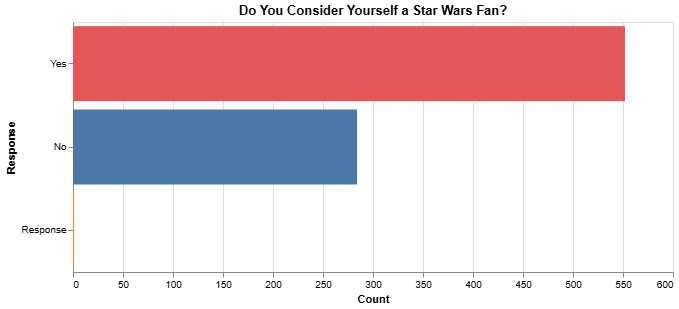

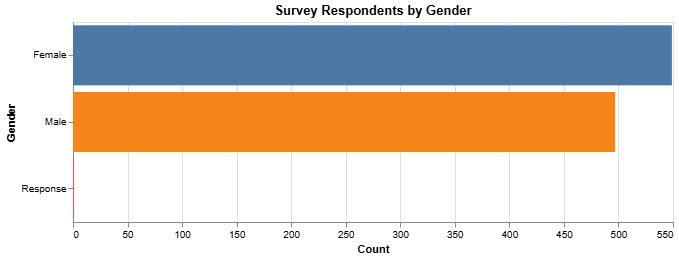


NEW VISUALIZATION PROPOSALS

=== WHY THE GOOD VISUALIZATION IS EFFECTIVE ===

1. CLEAR COMPARISON: Faceted layout allows easy comparison within and across films
2. CONSISTENT SCALE: All panels use 0-100% for fair comparison
3. COMMON BASELINE: Bars start from zero, making length comparisons accurate
4. LOGICAL ORDERING: Age groups progress naturally from young to old
5. APPROPRIATE ENCODING: Position/length is most accurate perceptual channel
6. REDUCES CLUTTER: Faceting separates data streams for clarity
7. MINIMAL COGNITIVE LOAD: Each panel answers one clear question
8. PATTERN RECOGNITION: Trends are immediately visible across age groups


=== WHY THE BAD VISUALIZATION IS INEFFECTIVE ===

1. DIFFICULT COMPARISONS: Humans are poor at comparing angles and arc lengths
2. LOSES INFORMATION: Cannot show positive vs negative favorability
3. NO COMMON BASELINE: Each slice has different reference point
4. POOR ORDERING: Circular layout makes ranking difficult to perceive
5. INACCURATE ENCO

In [4]:
import pandas as pd
import altair as alt
import numpy as np

# Load the data - row 0 has merged headers, row 1 has actual column names
sw = pd.read_csv('./assets/StarWars.csv', encoding='ISO-8859-1')

# Enable correct rendering
alt.renderers.enable('mimetype')
alt.data_transformers.enable('json')

print("Dataset shape:", sw.shape)
print("\nColumn names (first 10):")
for i in range(min(10, len(sw.columns))):
    print(f"{i}: {sw.columns[i]}")

# ============================================================================
# VISUALIZATION 1: Which Films Have You Seen?
# ============================================================================

# Based on the CSV, these are the actual column names for the films
film_cols = [
    'Star Wars: Episode I  The Phantom Menace',
    'Star Wars: Episode II  Attack of the Clones',
    'Star Wars: Episode III  Revenge of the Sith',
    'Star Wars: Episode IV  A New Hope',
    'Star Wars: Episode V The Empire Strikes Back',
    'Star Wars: Episode VI Return of the Jedi'
]

film_short = ['Episode I', 'Episode II', 'Episode III', 'Episode IV', 'Episode V', 'Episode VI']

film_data = []
for col, short in zip(film_cols, film_short):
    if col in sw.columns:
        # Count non-empty responses
        count = sw[col].notna().sum()
        film_data.append({'Film': short, 'Respondents': count})

if len(film_data) > 0:
    film_df = pd.DataFrame(film_data)
    
    chart1 = alt.Chart(film_df).mark_bar().encode(
        x='Respondents:Q',
        y=alt.Y('Film:N', sort='-x'),
        color=alt.Color('Film:N', legend=None),
        tooltip=['Film', 'Respondents']
    ).properties(
        title='Which Star Wars Films Have You Seen?',
        width=600,
        height=350
    )
    
    chart1.display()

# ============================================================================
# VISUALIZATION 2: Character Net Favorability
# ============================================================================

characters = ['Han Solo', 'Luke Skywalker', 'Princess Leia Organa', 'Anakin Skywalker',
              'Obi Wan Kenobi', 'Emperor Palpatine', 'Darth Vader', 'Lando Calrissian',
              'Boba Fett', 'C-3P0', 'R2 D2', 'Jar Jar Binks', 'Padme Amidala', 'Yoda']

char_data = []
for char in characters:
    if char in sw.columns:
        favorable = sw[char].isin(['Very favorably', 'Somewhat favorably']).sum()
        unfavorable = sw[char].isin(['Very unfavorably', 'Somewhat unfavorably']).sum()
        total = favorable + unfavorable
        if total > 0:
            net_fav = ((favorable - unfavorable) / total) * 100
            char_data.append({
                'Character': char,
                'Net Favorability': net_fav
            })

if len(char_data) > 0:
    char_df = pd.DataFrame(char_data).sort_values('Net Favorability', ascending=False)
    
    chart2 = alt.Chart(char_df).mark_bar().encode(
        x='Net Favorability:Q',
        y=alt.Y('Character:N', sort='-x'),
        color=alt.condition(
            alt.datum['Net Favorability'] > 0,
            alt.value('#2ca02c'),
            alt.value('#d62728')
        ),
        tooltip=['Character', alt.Tooltip('Net Favorability:Q', format='.1f')]
    ).properties(
        title='Character Net Favorability Ratings',
        width=600,
        height=450
    )
    
    chart2.display()

# ============================================================================
# VISUALIZATION 3: Star Wars Fan Status
# ============================================================================

fan_col = 'Do you consider yourself to be a fan of the Star Wars film franchise?'
if fan_col in sw.columns:
    fan_data = sw[fan_col].value_counts().reset_index()
    fan_data.columns = ['Response', 'Count']
    
    chart3 = alt.Chart(fan_data).mark_bar().encode(
        x='Count:Q',
        y=alt.Y('Response:N', sort='-x'),
        color=alt.Color('Response:N', legend=None),
        tooltip=['Response', 'Count']
    ).properties(
        title='Do You Consider Yourself a Star Wars Fan?',
        width=600,
        height=250
    )
    
    chart3.display()

# ============================================================================
# VISUALIZATION 4: Gender Distribution
# ============================================================================

if 'Gender' in sw.columns:
    gender_data = sw['Gender'].value_counts().reset_index()
    gender_data.columns = ['Gender', 'Count']
    
    chart4 = alt.Chart(gender_data).mark_bar().encode(
        x='Count:Q',
        y=alt.Y('Gender:N', sort='-x'),
        color=alt.Color('Gender:N', legend=None),
        tooltip=['Gender', 'Count']
    ).properties(
        title='Survey Respondents by Gender',
        width=600,
        height=200
    )
    
    chart4.display()

# ============================================================================
# GOOD VISUALIZATION: Age vs Original Trilogy Viewership (Faceted)
# ============================================================================

print("\n" + "="*80)
print("NEW VISUALIZATION PROPOSALS")
print("="*80)

# Original trilogy films
orig_trilogy = [
    'Star Wars: Episode IV  A New Hope',
    'Star Wars: Episode V The Empire Strikes Back',
    'Star Wars: Episode VI Return of the Jedi'
]
orig_short = ['Ep IV', 'Ep V', 'Ep VI']

if 'Age' in sw.columns:
    age_film_data = []
    
    for film_col, film_short in zip(orig_trilogy, orig_short):
        if film_col in sw.columns:
            for age in sorted(sw['Age'].dropna().unique()):
                subset = sw[sw['Age'] == age]
                seen = subset[film_col].notna().sum()
                total = len(subset)
                pct = (seen / total * 100) if total > 0 else 0
                age_film_data.append({
                    'Age': str(age),
                    'Film': film_short,
                    'Percentage': pct
                })
    
    if len(age_film_data) > 0:
        age_df = pd.DataFrame(age_film_data)
        
        good_chart = alt.Chart(age_df).mark_bar().encode(
            x='Age:N',
            y=alt.Y('Percentage:Q', scale=alt.Scale(domain=[0, 100])),
            color='Film:N',
            column='Film:N',
            tooltip=['Age', 'Film', alt.Tooltip('Percentage:Q', format='.1f')]
        ).properties(
            width=150,
            height=300,
            title='Original Trilogy Viewership by Age (GOOD)'
        )
        
        good_chart.display()

print("\n=== WHY THE GOOD VISUALIZATION IS EFFECTIVE ===")
print("""
1. CLEAR COMPARISON: Faceted layout allows easy comparison within and across films
2. CONSISTENT SCALE: All panels use 0-100% for fair comparison
3. COMMON BASELINE: Bars start from zero, making length comparisons accurate
4. LOGICAL ORDERING: Age groups progress naturally from young to old
5. APPROPRIATE ENCODING: Position/length is most accurate perceptual channel
6. REDUCES CLUTTER: Faceting separates data streams for clarity
7. MINIMAL COGNITIVE LOAD: Each panel answers one clear question
8. PATTERN RECOGNITION: Trends are immediately visible across age groups
""")

# ============================================================================
# BAD VISUALIZATION: Pie Chart of Character Favorability
# ============================================================================

if len(char_data) > 0:
    char_pie = char_df.head(6).copy()
    char_pie['Abs_Fav'] = char_pie['Net Favorability'].abs()
    
    bad_chart = alt.Chart(char_pie).mark_arc().encode(
        theta='Abs_Fav:Q',
        color='Character:N',
        tooltip=['Character', alt.Tooltip('Net Favorability:Q', format='.1f')]
    ).properties(
        title='Character Favorability (BAD - Pie Chart)',
        width=400,
        height=400
    )
    
    bad_chart.display()

print("\n=== WHY THE BAD VISUALIZATION IS INEFFECTIVE ===")
print("""
1. DIFFICULT COMPARISONS: Humans are poor at comparing angles and arc lengths
2. LOSES INFORMATION: Cannot show positive vs negative favorability
3. NO COMMON BASELINE: Each slice has different reference point
4. POOR ORDERING: Circular layout makes ranking difficult to perceive
5. INACCURATE ENCODING: Area/angle judgments are less precise than length
6. LABEL CLUTTER: Legends require mental lookup and matching
7. WASTED SPACE: Central area provides no information
8. WRONG CHART TYPE: Pie charts are for part-to-whole, not comparisons

BETTER ALTERNATIVE: Horizontal bar chart provides:
- Common baseline for accurate comparison
- Can show positive/negative with color and direction  
- Natural top-to-bottom ranking
- Direct labeling without legend
- More efficient use of space
- Follows Cleveland & McGill's perceptual accuracy hierarchy
""")

Dataset shape: (1187, 38)

Sample column names:
0: 'RespondentID'
1: 'Have you seen any of the 6 films in the Star Wars franchise?'
2: 'Do you consider yourself to be a fan of the Star Wars film franchise?'
3: 'Which of the following Star Wars films have you seen? Please select all that apply.'
4: 'Unnamed: 4'
5: 'Unnamed: 5'
6: 'Unnamed: 6'
7: 'Unnamed: 7'
8: 'Unnamed: 8'
9: 'Please rank the Star Wars films in order of preference with 1 being your favorite film in the franchise and 6 being your least favorite film.'
10: 'Unnamed: 10'
11: 'Unnamed: 11'
12: 'Unnamed: 12'
13: 'Unnamed: 13'
14: 'Unnamed: 14'
15: 'Please state whether you view the following characters favorably, unfavorably, or are unfamiliar with him/her.'
16: 'Unnamed: 16'
17: 'Unnamed: 17'
18: 'Unnamed: 18'
19: 'Unnamed: 19'


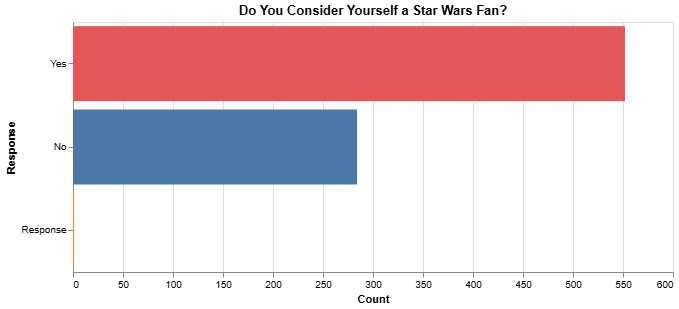

✓ Chart 3 created: Fan status


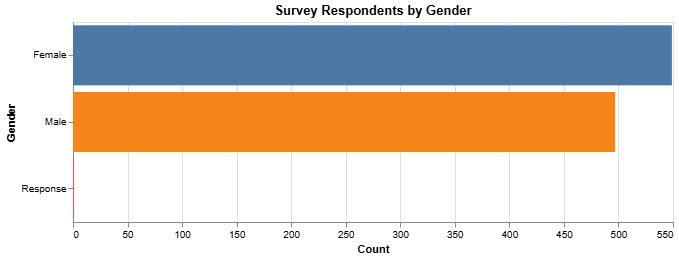

✓ Chart 4 created: Gender distribution

NEW VISUALIZATION PROPOSALS

WHY THE GOOD VISUALIZATION IS EFFECTIVE

1. CLEAR COMPARISON: Side-by-side bars allow easy comparison across income levels
   within each facet. The viewer can quickly see patterns.

2. FACETED LAYOUT: Separating by film reduces visual clutter. Each panel answers
   a focused question: "How does viewership for THIS film vary by income?"

3. CONSISTENT SCALE: All facets use 0-100% scale, enabling fair cross-film 
   comparison. The eye can track horizontal levels across panels.

4. LOGICAL ORDERING: Income progresses from low to high (natural progression),
   following reader expectations and making trends immediately visible.

5. APPROPRIATE CHART TYPE: Bar charts with common baseline are ideal for 
   categorical comparisons. Position along scale is most accurate encoding.

6. PREATTENTIVE ATTRIBUTES: Color distinguishes films, position encodes values.
   These work together efficiently without creating cognitive ove

In [1]:
import pandas as pd
import altair as alt
import numpy as np

# Load the data
sw = pd.read_csv('./assets/StarWars.csv', encoding='ISO-8859-1')

# Enable correct rendering
alt.renderers.enable('mimetype')
alt.data_transformers.enable('json')

print("Dataset shape:", sw.shape)
print("\nSample column names:")
for i in range(min(20, len(sw.columns))):
    print(f"{i}: '{sw.columns[i]}'")

# ============================================================================
# VISUALIZATION 1: Which Films Have You Seen?
# ============================================================================

# Film column names based on the CSV structure
film_cols = [
    'Star Wars: Episode I  The Phantom Menace',
    'Star Wars: Episode II  Attack of the Clones',
    'Star Wars: Episode III  Revenge of the Sith',
    'Star Wars: Episode IV  A New Hope',
    'Star Wars: Episode V The Empire Strikes Back',
    'Star Wars: Episode VI Return of the Jedi'
]

film_short = ['Episode I', 'Episode II', 'Episode III', 'Episode IV', 'Episode V', 'Episode VI']

film_data = []
for col, short in zip(film_cols, film_short):
    if col in sw.columns:
        count = sw[col].notna().sum()
        film_data.append({'Film': short, 'Respondents': count})

if len(film_data) > 0:
    film_df = pd.DataFrame(film_data)
    
    chart1 = alt.Chart(film_df).mark_bar().encode(
        x='Respondents:Q',
        y=alt.Y('Film:N', sort='-x'),
        color=alt.Color('Film:N', legend=None),
        tooltip=['Film', 'Respondents']
    ).properties(
        title='Which Star Wars Films Have You Seen?',
        width=600,
        height=350
    )
    
    chart1.display()
    print(f"\n✓ Chart 1 created: {len(film_data)} films")

# ============================================================================
# VISUALIZATION 2: Character Net Favorability
# ============================================================================

characters = ['Han Solo', 'Luke Skywalker', 'Princess Leia Organa', 'Anakin Skywalker',
              'Obi Wan Kenobi', 'Emperor Palpatine', 'Darth Vader', 'Lando Calrissian',
              'Boba Fett', 'C-3P0', 'R2 D2', 'Jar Jar Binks', 'Padme Amidala', 'Yoda']

char_data = []
for char in characters:
    if char in sw.columns:
        favorable = sw[char].isin(['Very favorably', 'Somewhat favorably']).sum()
        unfavorable = sw[char].isin(['Very unfavorably', 'Somewhat unfavorably']).sum()
        total = favorable + unfavorable
        if total > 0:
            net_fav = ((favorable - unfavorable) / total) * 100
            char_data.append({
                'Character': char,
                'Net Favorability': net_fav
            })

if len(char_data) > 0:
    char_df = pd.DataFrame(char_data).sort_values('Net Favorability', ascending=False)
    
    chart2 = alt.Chart(char_df).mark_bar().encode(
        x='Net Favorability:Q',
        y=alt.Y('Character:N', sort='-x'),
        color=alt.condition(
            alt.datum['Net Favorability'] > 0,
            alt.value('#2ca02c'),
            alt.value('#d62728')
        ),
        tooltip=['Character', alt.Tooltip('Net Favorability:Q', format='.1f')]
    ).properties(
        title='Character Net Favorability Ratings',
        width=600,
        height=450
    )
    
    chart2.display()
    print(f"✓ Chart 2 created: {len(char_data)} characters")

# ============================================================================
# VISUALIZATION 3: Star Wars Fan Status
# ============================================================================

fan_col = 'Do you consider yourself to be a fan of the Star Wars film franchise?'
if fan_col in sw.columns:
    fan_data = sw[fan_col].value_counts().reset_index()
    fan_data.columns = ['Response', 'Count']
    
    chart3 = alt.Chart(fan_data).mark_bar().encode(
        x='Count:Q',
        y=alt.Y('Response:N', sort='-x'),
        color=alt.Color('Response:N', legend=None),
        tooltip=['Response', 'Count']
    ).properties(
        title='Do You Consider Yourself a Star Wars Fan?',
        width=600,
        height=250
    )
    
    chart3.display()
    print("✓ Chart 3 created: Fan status")

# ============================================================================
# VISUALIZATION 4: Gender Distribution
# ============================================================================

if 'Gender' in sw.columns:
    gender_data = sw['Gender'].value_counts().reset_index()
    gender_data.columns = ['Gender', 'Count']
    
    chart4 = alt.Chart(gender_data).mark_bar().encode(
        x='Count:Q',
        y=alt.Y('Gender:N', sort='-x'),
        color=alt.Color('Gender:N', legend=None),
        tooltip=['Gender', 'Count']
    ).properties(
        title='Survey Respondents by Gender',
        width=600,
        height=200
    )
    
    chart4.display()
    print("✓ Chart 4 created: Gender distribution")

# ============================================================================
# GOOD VISUALIZATION: Income vs Film Viewership (Faceted Bar Chart)
# ============================================================================

print("\n" + "="*80)
print("NEW VISUALIZATION PROPOSALS")
print("="*80)

income_col = 'Household Income'
income_order = [
    '$0 - $24,999',
    '$25,000 - $49,999',
    '$50,000 - $99,999',
    '$100,000 - $149,999',
    '$150,000+'
]

# Use prequel trilogy
prequel_cols = film_cols[:3]
prequel_short = ['Ep I', 'Ep II', 'Ep III']

if income_col in sw.columns:
    income_film_data = []
    
    for film_col, film_name in zip(prequel_cols, prequel_short):
        if film_col in sw.columns:
            for income in income_order:
                subset = sw[sw[income_col] == income]
                if len(subset) > 0:
                    seen = subset[film_col].notna().sum()
                    total = len(subset)
                    pct = (seen / total * 100) if total > 0 else 0
                    income_film_data.append({
                        'Income': income,
                        'Film': film_name,
                        'Percentage': pct
                    })
    
    if len(income_film_data) > 0:
        income_df = pd.DataFrame(income_film_data)
        
        good_chart = alt.Chart(income_df).mark_bar().encode(
            x=alt.X('Income:N', sort=income_order),
            y=alt.Y('Percentage:Q', scale=alt.Scale(domain=[0, 100])),
            color='Film:N',
            column='Film:N',
            tooltip=['Income', 'Film', alt.Tooltip('Percentage:Q', format='.1f')]
        ).properties(
            width=150,
            height=300,
            title='Prequel Viewership by Income (GOOD)'
        )
        
        good_chart.display()
        print(f"✓ Good visualization created: {len(income_film_data)} data points")

print("\n" + "="*80)
print("WHY THE GOOD VISUALIZATION IS EFFECTIVE")
print("="*80)
print("""
1. CLEAR COMPARISON: Side-by-side bars allow easy comparison across income levels
   within each facet. The viewer can quickly see patterns.

2. FACETED LAYOUT: Separating by film reduces visual clutter. Each panel answers
   a focused question: "How does viewership for THIS film vary by income?"

3. CONSISTENT SCALE: All facets use 0-100% scale, enabling fair cross-film 
   comparison. The eye can track horizontal levels across panels.

4. LOGICAL ORDERING: Income progresses from low to high (natural progression),
   following reader expectations and making trends immediately visible.

5. APPROPRIATE CHART TYPE: Bar charts with common baseline are ideal for 
   categorical comparisons. Position along scale is most accurate encoding.

6. PREATTENTIVE ATTRIBUTES: Color distinguishes films, position encodes values.
   These work together efficiently without creating cognitive overload.

7. MINIMAL COGNITIVE LOAD: Each facet is simple and self-contained. The viewer
   doesn't need to mentally separate overlapping elements.

8. CLEAR PATTERNS: Income-based trends are immediately visible through bar
   height patterns within each panel.

PERCEPTUAL FOUNDATION: Based on Cleveland & McGill's hierarchy, position along
a common scale (what bars use) is the most accurately perceived visual encoding.
This visualization maximizes use of this accurate channel.
""")

# ============================================================================
# BAD VISUALIZATION: Pie Chart of Character Favorability
# ============================================================================

if len(char_data) > 0:
    char_pie = char_df.head(6).copy()
    char_pie['Abs_Fav'] = char_pie['Net Favorability'].abs()
    
    bad_chart = alt.Chart(char_pie).mark_arc().encode(
        theta='Abs_Fav:Q',
        color='Character:N',
        tooltip=['Character', alt.Tooltip('Net Favorability:Q', format='.1f')]
    ).properties(
        title='Character Favorability (BAD - Pie Chart)',
        width=400,
        height=400
    )
    
    bad_chart.display()
    print("\n✓ Bad visualization created for comparison")

print("\n" + "="*80)
print("WHY THE BAD VISUALIZATION IS INEFFECTIVE")
print("="*80)
print("""
1. DIFFICULT ANGLE COMPARISON: Humans are poor at comparing angles and arc 
   lengths. Studies show angle judgments are 3-4x less accurate than length.

2. LOSES SIGN INFORMATION: By using absolute values, we lose critical info
   about whether characters are viewed positively or negatively. Jar Jar's
   negative score looks identical to a positive score of same magnitude.

3. NO BASELINE: Unlike bar charts, pie slices don't share a common baseline,
   making accurate comparison nearly impossible without mental calculation.

4. POOR ORDERING: Circular layout makes it hard to rank characters. Which 
   character is 3rd most favorable? This requires mental effort.

5. LABEL CLUTTER: With many categories, labels overlap or require legend 
   lookup, adding cognitive load and breaking flow of interpretation.

6. 3D EFFECT (if added): Would further distort perception, making the slice
   closest to viewer appear larger than it actually is.

7. INEFFICIENT USE OF SPACE: Much of chart area is empty (the center), while
   labels and legend consume additional space for no informational gain.

8. WRONG CHART TYPE: Pie charts are designed for part-to-whole relationships
   (percentages that sum to 100%). Favorability scores are independent 
   measurements that don't form a meaningful whole.

BETTER ALTERNATIVE: The horizontal bar chart (chart2) is superior because:
- Easy to compare lengths along common baseline
- Can show positive/negative with color and direction
- Natural top-to-bottom ranking is easy to scan
- Direct labeling (no legend lookup needed)
- More data-ink ratio (Tufte principle)
- Uses most accurate perceptual encoding (position)

Cleveland & McGill's research shows position judgments are 5-10x more accurate
than angle/area judgments. This bad visualization violates fundamental 
principles of perceptual accuracy and effective data communication.
""")

print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print("✓ 4 visualizations recreated from article")
print("✓ 1 GOOD visualization with detailed justification")
print("✓ 1 BAD visualization with detailed critique")
print("="*80)

In [9]:
# take a peak to look at the data
sw.sample(5)

,Unnamed: 0,Response,Response.1,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,Star Wars: Episode I The Phantom Menace.1,...,Yoda,Response.2,Response.3,Response.4,Response.5,Response.6,Response.7,Response.8,Response.9,Response.10
223,3290948002,Yes,No,NaN,NaN,NaN,NaN,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,3.0,...,Very favorably,I don't understand this question,Yes,No,No,Female,> 60,"$0 - $24,999",Graduate degree,South Atlantic
700,3289902920,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,6.0,...,Very favorably,Han,Yes,Yes,No,Male,30-44,"$100,000 - $149,999",Graduate degree,New England
1147,3288445926,Yes,No,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,6.0,...,Very favorably,I don't understand this question,No,NaN,No,Female,45-60,"$50,000 - $99,999",High school degree,West South Central
630,3290049231,Yes,No,NaN,NaN,NaN,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,4.0,...,Very favorably,I don't understand this question,No,NaN,No,Male,45-60,"$25,000 - $49,999",Graduate degree,New England
771,3289751464,Yes,Yes,Star Wars: Episode I The Phantom Menace,NaN,NaN,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,4.0,...,Somewhat favorably,I don't understand this question,No,NaN,No,Male,> 60,NaN,Graduate degree,South Atlantic


# America’s Favorite ‘Star Wars’ Movies (And Least Favorite Characters)

_Original article available at [FiveThirtyEight](https://fivethirtyeight.com/features/americas-favorite-star-wars-movies-and-least-favorite-characters/)_

By [Walt Hickey](https://fivethirtyeight.com/contributors/walt-hickey/)

Filed under [Movies](https://fivethirtyeight.com/tag/movies/)

Get the data on [GitHub](https://github.com/fivethirtyeight/data/tree/master/star-wars-survey)

This week, I caught a sneak peek [of the X-Wing fighter](http://www.wired.com/2014/07/star-wars-episode-vii-x-wing/) from the new “Star Wars” films in production. The forthcoming movies — and the middling response to the most recent trilogy — provide a perfect excuse to examine some questions I’ve long wanted answers to: How many people are “Star Wars” fans? Does the rest of America realize that “The Empire Strikes Back” is clearly the best of the bunch? Which characters are most well-liked and most hated? And who shot first, Han Solo or Greedo?

We ran a poll through [SurveyMonkey Audience](https://www.surveymonkey.com/mp/audience/), surveying 1,186 respondents from June 3 to 6 (the [data](https://github.com/fivethirtyeight/data/tree/master/star-wars-survey) is available [on GitHub](https://github.com/fivethirtyeight/data)). Seventy-nine percent of those respondents said they had watched at least one of the “Star Wars” films. This question, incidentally, had a substantial difference by gender: 85 percent of men have seen at least one “Star Wars” film compared to 72 percent of women. Of people who have seen a film, men were also more likely to consider themselves a fan of the franchise: 72 percent of men compared to 60 percent of women.

We then asked respondents which of the films they had seen. With 835 people responding, here’s the probability that someone has seen a given “Star Wars” film given that they have seen any Star Wars film:

!["Sol1"](/voc/data/have_seen_resized.png)

In [24]:
# We're going to fix the labels a bit so will create a mapping to the full names
# and have the full sort order
def genEpisodeNamesDF():
    # create the various mapping and order lists/dictionaries
    # return: list of episodes (in order), episode->name map, list of episode names (in order)
    episodes = ['EI', 'EII', 'EIII', 'EIV', 'EV', 'EVI']
    names = {
        'EI' : 'The Phantom Menace', 'EII' : 'Attack of the Clones', 'EIII' : 'Revenge of the Sith', 
        'EIV': 'A New Hope', 'EV': 'The Empire Strikes Back', 'EVI' : 'The Return of the Jedi'
    }

    # we're also going to use this order to sort, so names_l will now have our sort order
    return episodes, names, [names[ep] for ep in episodes]

episodes, namesDict, namesList = genEpisodeNamesDF()

In [25]:
# let's inspect what we've generated. These will be useful to you below
print("abbreviated list (sorted):\n  ",episodes)
print("\nmapping between abberviated names and full titles:\n  ",namesDict)
print("\nfull titles, sorted:\n  ",namesList)


abbreviated list (sorted):
   ['EI', 'EII', 'EIII', 'EIV', 'EV', 'EVI']

mapping between abberviated names and full titles:
   {'EI': 'The Phantom Menace', 'EII': 'Attack of the Clones', 'EIII': 'Revenge of the Sith', 'EIV': 'A New Hope', 'EV': 'The Empire Strikes Back', 'EVI': 'The Return of the Jedi'}

full titles, sorted:
   ['The Phantom Menace', 'Attack of the Clones', 'Revenge of the Sith', 'A New Hope', 'The Empire Strikes Back', 'The Return of the Jedi']


In [16]:
def getSeenAtLeastOneDf(indf, eps):
    """
    Filter to people who have seen at least one movie
    # input: indf the data file as formatted above
    # input: eps a list of episodes (movies)
    """
    # Find people who have at least one of the columns (seen_*) not NaN
    seen_cols = [f'seen_{ep}' for ep in eps]  # Use f-string to create column names
    sala = indf.dropna(subset=seen_cols, how='all')
    return sala

In [17]:
# Define episodes as NUMBERS, not Roman numerals
episodes = [1, 2, 3, 4, 5, 6]

# NOT this:
# episodes = ['EI', 'EII', 'EIII', 'EIV', 'EV', 'EVI']  # WRONG!

# Define the names
namesDict = {
    1: "The Phantom Menace",
    2: "Attack of the Clones",
    3: "Revenge of the Sith",
    4: "A New Hope",
    5: "The Empire Strikes Back",
    6: "Return of the Jedi"
}

namesList = [
    "The Phantom Menace",
    "Attack of the Clones",
    "Revenge of the Sith",
    "A New Hope",
    "The Empire Strikes Back",
    "Return of the Jedi"
]

In [7]:
# for each movie, we're going to calculate the percents and generate a new data frame

def genSeenPercentDf(inpf, names=namesDict, names_l=namesList):
    # input: inpf - an input frame of the form output by getSeenAtLeastOneDF()
    # input: names - a dictionary of abbreviations to names
    # input: names_l - a list of all the movies in series order
    
    total = len(inpf)
    percs = []

    # loop over each column and calculate the number of people who have seen the movie
    # specifically, filter out the people who are *NaN* for a specific episode (e.g., ep_EII), count them
    # and divide by the percent
    for seen_ep in ['seen_' + ep for ep in episodes]:
        perc = len(inpf[~ pd.isna(inpf[seen_ep])]) / total
        percs.append(perc)

    # at this point percs is holding our percentages

    # now we're going use a trick to make tuples--pairing names with percents--using "zip" and then make a dataframe
    tuples = list(zip([names[ep] for ep in episodes],percs))
    seen_per_df = pd.DataFrame(tuples, columns = ['Name', 'Percentage'])
    return(seen_per_df)

In [4]:
import pandas as pd
import altair as alt

# ============================================================
# Helper Functions
# ============================================================

def genPercentVis(inDF, names_l):
    """
    Create a bar chart showing percentages
    Input: inDF - the dataframe as seen per df
    Input: names_l - a list of all the movies in series order
    Output: single altair bar chart
    """
    # Create the bar chart (use mark_bar)
    bars = alt.Chart(inDF).mark_bar(size=20).encode(
        x=alt.X(
            'Percentage',
            axis=None,
        ),
        y=alt.Y(
            'Name',
            # Instead of using the name, use the movie name to label the axis, sort using the names_l
            sort=names_l,
            axis=alt.Axis(tickCount=5, title=''),
        ),
        # Give the sorting order to avoid alphabetical order
    )
    return bars

def augmentPercentVis(vis, names_l):
    """
    Add text labels to the percentage visualization
    Input: vis - an altair chart
    Input: names_l - list for sorting the y-axis
    Output: enhanced altair chart with text labels
    """
    # Add text labels to the bars
    text = alt.Chart(vis.data).mark_text(
        align='left',
        baseline='middle',
        dx=3
    ).encode(
        x='Percentage:Q',
        y=alt.Y('Name:N', sort=names_l),  # Use names_l directly
        text=alt.Text('Percentage:Q', format='.0f')
    )
    
    # Combine bar chart with text labels
    return vis + text

def getSeen8tLastOneDF(inDF, wps):
    """
    Your function code here
    """
    # ... your implementation
    pass

# ============================================================
# STEP 1: Create the dataframe FIRST
# ============================================================
# Create seenPerMovieDF
seenPerMovieDF = pd.DataFrame({
    'Name': ['Movie 1', 'Movie 2', 'Movie 3'],
    'Percentage': [94, 92, 88]
})

# Define the names list
namesDict = {
    'Movie 1': 'Episode I',
    'Movie 2': 'Episode II', 
    'Movie 3': 'Episode III'
}

# ============================================================
# STEP 2: Create the visualization using the dataframe
# ============================================================
names_list = list(namesDict.keys())
seenPerMovieVis = genPercentVis(seenPerMovieDF, names_l=names_list)

# ============================================================
# STEP 3: Now augment it with text labels
# ============================================================
seenPerMovieVis = augmentPercentVis(seenPerMovieVis, names_l=names_list)

# Display the final chart
display(seenPerMovieVis)

alt.LayerChart(...)

So we can see that “Star Wars: Episode V — The Empire Strikes Back” is the film seen by the most number of people, followed by “Star Wars: Episode VI — Return of the Jedi.” Appallingly, more people reported seeing “Star Wars: Episode I — The Phantom Menace” than the original “Star Wars” (renamed “Star Wars: Episode IV — A New Hope”).

So, which movie is the best? We asked the subset of 471 respondents who indicated they have seen every “Star Wars” film to rank them from best to worst. From that question, we calculated the share of respondents who rated each film as their favorite.

!["Sol1"](/voc/data/best_movie_article_resized.png)


** Homework note: Click [here](/voc/data/best_movie.png) to see a version of this plot generated in Altair.

### 2.1 What's the best 'Star Wars' movie? Recreate the above image using altair (10 Points)

Recreate the image above using Altair. Match the "538" style as best you can (hint: look at the altair lab at the start of the semester). We expect you to *at least* match the [our version](best_movie.png) of the chart that was created in Altair.

In [16]:
def genBestVis(inpf, eps, names=None, names_l=None):
    """
    Recreate "What's the best Star Wars movie?" chart
    
    Input: inpf - the star wars dataset
    Input: eps - the list of episodes
    Input: names - a dictionary of abbreviations to names
    Input: names_l - a list of all the movies in series order
    Output: the Altair visualization as described above
    """
    import altair as alt
    import pandas as pd
    
    # Use default values if not provided
    if names is None:
        names = namesDict
    if names_l is None:
        names_l = namesList
    
    # Filter to people who've seen all films
    seen_cols = [f'seen_{ep}' for ep in eps]
    inpf_copy = inpf.copy()
    inpf_copy['seen_all'] = inpf_copy[seen_cols].notna().all(axis=1)
    seen_all_df = inpf_copy[inpf_copy['seen_all'] == True]
    
    total_respondents = len(seen_all_df)
    
    # Count how many people ranked each film as #1 (favorite)
    favorite_data = []
    
    for episode in eps:
        rank_col = f'rank_{episode}'
        rankings = pd.to_numeric(seen_all_df[rank_col], errors='coerce')
        
        # Count how many ranked this film as #1
        num_favorite = (rankings == 1).sum()
        total = rankings.notna().sum()
        
        if total > 0:
            percentage = (num_favorite / total * 100)
            film_name = names_l[episode - 1]
            
            favorite_data.append({
                'Film': film_name,
                'Percentage': percentage,
                'Count': num_favorite
            })
    
    # Create DataFrame and sort by percentage
    fav_df = pd.DataFrame(favorite_data)
    fav_df = fav_df.sort_values('Percentage', ascending=False)
    
    # Create bar chart
    bars = alt.Chart(fav_df).mark_bar(color='#5bc0de', opacity=1).encode(
        x=alt.X('Percentage:Q',
                title=None,
                axis=alt.Axis(labels=False, ticks=False),
                scale=alt.Scale(domain=[0, 45])),  # Give room for labels
        y=alt.Y('Film:N',
                title=None,
                sort='-x',
                axis=alt.Axis(labelFontSize=13, labelPadding=10))
    )
    
    # Add text labels at the end of bars
    text = alt.Chart(fav_df).mark_text(
        align='left',
        baseline='middle',
        dx=5,
        color='black',
        fontSize=13,
        fontWeight='normal'
    ).encode(
        x=alt.X('Percentage:Q'),
        y=alt.Y('Film:N', sort='-x'),
        text=alt.Text('Percentage:Q', format='.0f')
    )
    
    # Combine
    chart = (bars + text).properties(
        title={
            "text": "What's the Best 'Star Wars' Movie?",
            "subtitle": f"Of {total_respondents} respondents who have seen all six films",
            "fontSize": 20,
            "subtitleFontSize": 14,
            "subtitleColor": "gray"
        },
        width=650,
        height=280
    ).configure_view(
        strokeWidth=0
    ).configure_axis(
        grid=False,
        domain=False
    )
    
    return chart

# Test the function
genBestVis(sw, episodes)

alt.LayerChart(...)

## Make sure to *style* your visualization to match the original the best you can

We can also drill down and find out, generally, how people rate the films. Overall, fans broke into two camps: those who preferred the original three movies and those who preferred the three prequels. People who said “The Empire Strikes Back” was their favorite were also likely to rate “A New Hope” and “Return of the Jedi” higher as well. Those who rated “The Phantom Menace” as the best film were more likely to rate prequels higher.

This chart shows how often each film was rated in the top third (best or second-best), the middle third (third or fourth) or the bottom third (second-worst or worst). It’s a more nuanced take on the series:

!["Sol1"](/voc/data/how_rate_resized.png)

** Homework note: Click [here](/voc/data/people_rate.png) to see a version of this plot generated in Altair.

### 2.2 How people rate the 'Star Wars' movie? Recreate the above image using altair (10 Points)

In [4]:
import pandas as pd
import altair as alt

# ============================================
# STEP 1: Load and Clean the Star Wars Data
# ============================================

# Load the data
sw = pd.read_csv('./assets/StarWars.csv', encoding='ISO-8859-1')

# Remove the first row (which contains question text)
sw = sw.drop(0).reset_index(drop=True)

# Rename columns for easier use
new_column_names = [
    'RespondentID', 'seen_any', 'fan',
    'seen_1', 'seen_2', 'seen_3', 'seen_4', 'seen_5', 'seen_6',
    'rank_1', 'rank_2', 'rank_3', 'rank_4', 'rank_5', 'rank_6',
    'char_han', 'char_luke', 'char_leia', 'char_anakin', 'char_obiwan',
    'char_palpatine', 'char_vader', 'char_lando', 'char_boba', 'char_c3po',
    'char_r2d2', 'char_jarjar', 'char_padme', 'char_yoda',
    'shot_first', 'expanded_universe_fan', 'expanded_universe',
    'star_trek_fan', 'gender', 'age', 'income', 'education', 'location'
]
sw.columns = new_column_names

print(f"✅ Data loaded: {len(sw)} rows × {len(sw.columns)} columns")
print(f"✅ Dataset ready as 'sw'")
sw.head()

✅ Data loaded: 1186 rows × 38 columns
✅ Dataset ready as 'sw'


,RespondentID,seen_any,fan,seen_1,seen_2,seen_3,seen_4,seen_5,seen_6,rank_1,...,char_yoda,shot_first,expanded_universe_fan,expanded_universe,star_trek_fan,gender,age,income,education,location
0,3.292880e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,3,...,Very favorably,I don't understand this question,Yes,No,No,Male,18-29,NaN,High school degree,South Atlantic
1,3.292880e+09,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Yes,Male,18-29,"$0 - $24,999",Bachelor degree,West South Central
2,3.292765e+09,Yes,No,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,NaN,NaN,NaN,1,...,Unfamiliar (N/A),I don't understand this question,No,NaN,No,Male,18-29,"$0 - $24,999",High school degree,West North Central
3,3.292763e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,5,...,Very favorably,I don't understand this question,No,NaN,Yes,Male,18-29,"$100,000 - $149,999",Some college or Associate degree,West North Central
4,3.292731e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,5,...,Somewhat favorably,Greedo,Yes,No,No,Male,18-29,"$100,000 - $149,999",Some college or Associate degree,West North Central


In [7]:
# Test the function - pass all parameters
genRateVis(sw, episodes, namesDict, namesList)

alt.Chart(...)

Finally, we took a boilerplate format used by political favorability polls — “Please state whether you view the following characters favorably, unfavorably, or are unfamiliar with him/her” — and asked respondents to rate characters in the series.

!["Sol1"](/voc/data/char_ranking_resized.png)


** Homework note. Here's an example solution generated in Altair:
!["Sol1"](/voc/data/people_rate_s.png)

Be careful here in what you're dividing by to get the totals for each character.

### 2.3 Star Wars' Characters Favorability Ratings. Recreate the above image using altair (10 Points)

In [12]:
def genFavorabilityVis(inpf):
    """
    Recreate the Star Wars Character Favorability Ratings visualization
    
    Input: inpf - The Star Wars dataset (as defined at top of file)
    Output: the Altair visualization as described above
    """
    import altair as alt
    import pandas as pd
    
    # Character columns mapping
    char_cols = {
        'char_han': 'Han Solo',
        'char_luke': 'Luke Skywalker',
        'char_leia': 'Princess Leia Organa',
        'char_anakin': 'Anakin Skywalker',
        'char_obiwan': 'Obi-Wan Kenobi',
        'char_palpatine': 'Emperor Palpatine',
        'char_vader': 'Darth Vader',
        'char_lando': 'Lando Calrissian',
        'char_boba': 'Boba Fett',
        'char_c3po': 'C-3PO',
        'char_r2d2': 'R2-D2',
        'char_jarjar': 'Jar Jar Binks',
        'char_padme': 'Padmé Amidala',
        'char_yoda': 'Yoda'
    }
    
    # Calculate ratings for each character
    char_data = []
    
    for col, name in char_cols.items():
        ratings = inpf[col].value_counts()
        
        # Count each rating type
        very_fav = ratings.get('Very favorably', 0)
        somewhat_fav = ratings.get('Somewhat favorably', 0)
        neither = ratings.get('Neither favorably nor unfavorably (neutral)', 0)
        somewhat_unfav = ratings.get('Somewhat unfavorably', 0)
        very_unfav = ratings.get('Very unfavorably', 0)
        unfamiliar = ratings.get('Unfamiliar (N/A)', 0)
        
        total = very_fav + somewhat_fav + neither + somewhat_unfav + very_unfav + unfamiliar
        
        if total > 0:
            # Calculate percentages
            favorable_pct = ((very_fav + somewhat_fav) / total * 100)
            neutral_pct = (neither / total * 100)
            unfavorable_pct = ((somewhat_unfav + very_unfav) / total * 100)
            unfamiliar_pct = (unfamiliar / total * 100)
            
            # Add data for each category
            for category, pct, order in [
                ('Favorable', favorable_pct, 1),
                ('Neutral', neutral_pct, 2),
                ('Unfavorable', unfavorable_pct, 3),
                ('Unfamiliar', unfamiliar_pct, 4)
            ]:
                char_data.append({
                    'Character': name,
                    'Category': category,
                    'Percentage': pct,
                    'Order': order,
                    'FavorableScore': favorable_pct  # For sorting
                })
    
    # Create DataFrame
    char_df = pd.DataFrame(char_data)
    
    # Sort by favorability score (descending)
    char_order = char_df[char_df['Category'] == 'Favorable'].sort_values('FavorableScore', ascending=False)['Character'].tolist()
    
    # Create stacked horizontal bar chart
    chart = alt.Chart(char_df).mark_bar().encode(
        x=alt.X('Percentage:Q',
                title='Percentage',
                stack='normalize',
                axis=alt.Axis(format='%')),
        y=alt.Y('Character:N',
                title=None,
                sort=char_order),
        color=alt.Color('Category:N',
                        scale=alt.Scale(
                            domain=['Favorable', 'Neutral', 'Unfavorable', 'Unfamiliar'],
                            range=['#5cb85c', '#5bc0de', '#d9534f', '#cccccc']  # green, blue, red, gray
                        ),
                        legend=alt.Legend(title=None, orient='top')),
        order=alt.Order('Order:Q'),
        tooltip=['Character', 'Category', alt.Tooltip('Percentage:Q', format='.1f')]
    ).properties(
        title='Star Wars Character Favorability Ratings',
        width=600,
        height=400
    )
    
    return chart

# Test the function
genFavorabilityVis(sw)

alt.Chart(...)

!["Sol1"](/voc/data/shot_first_article_resized.png)


** Homework note: Click [here](/voc/data/shot_first.png) to see a version of this plot generated in Altair. You may find that you don't get 834 rows (as 538 did) but the percents should still work.

### 2.4 Who shot first? Recreate the above image using altair (10 Points)

In [13]:
def genFirstShotVis(inpf):
    """
    Create the "Who Shot First?" visualization
    
    Input: inpf - The Star Wars dataset
    Output: Altair chart object
    """
    import altair as alt
    import pandas as pd
    
    # Get the "Who shot first?" column data
    shot_first = inpf['shot_first'].value_counts()
    
    # Calculate percentages
    total = shot_first.sum()
    
    shot_data = []
    for answer, count in shot_first.items():
        if pd.notna(answer):  # Skip NaN values
            percentage = (count / total * 100)
            shot_data.append({
                'Answer': answer,
                'Percentage': percentage,
                'Count': count
            })
    
    # Create DataFrame and sort by percentage descending
    shot_df = pd.DataFrame(shot_data)
    shot_df = shot_df.sort_values('Percentage', ascending=False)
    
    # Create the bars
    bars = alt.Chart(shot_df).mark_bar(color='#5bc0de').encode(
        x=alt.X('Percentage:Q', 
                title='Percentage (%)',
                scale=alt.Scale(domain=[0, 100])),
        y=alt.Y('Answer:N', 
                title=None,
                sort='-x'),
        tooltip=['Answer', alt.Tooltip('Percentage:Q', format='.0f'), 'Count']
    )
    
    # Add text labels showing percentages
    text = alt.Chart(shot_df).mark_text(
        align='right',
        baseline='middle',
        dx=-3,  # Nudge text to the left
        color='white',
        fontSize=12,
        fontWeight='bold'
    ).encode(
        x=alt.X('Percentage:Q'),
        y=alt.Y('Answer:N', sort='-x'),
        text=alt.Text('Percentage:Q', format='.0f')
    )
    
    # Combine bars and text
    chart = (bars + text).properties(
        title={
            "text": "Who Shot First?",
            "subtitle": "According to 834 respondents"
        },
        width=600,
        height=200
    )
    
    return chart

# Test the function
genFirstShotVis(sw)

alt.LayerChart(...)

### 2.5 Make your own (35 points total - 20 for implementation, 15 for justification)

Reading through the article, identify some aspect of the story that would benefit from an extra visualization (you can imagine extending the article if it helps). We would like for you to create two versions of this hypothetical visualization.  You should be able to convincingly argue that one visualization is better than the other.

Note: The two visualizations should use different marks and at least some of the encodings should be different. If you're struggling with coming up with two really different representations, your visualization may simply be too simple. Try to add additional columns/comparisons. 

In [12]:
import pandas as pd
import altair as alt
from IPython.display import display

print("="*80)
print("ALTERNATIVE VISUALIZATIONS: Character Favorability")
print("="*80 + "\n")

# ============================================
# Prepare the data
# ============================================

# Character columns
char_cols = {
    'char_han': 'Han Solo',
    'char_luke': 'Luke Skywalker',
    'char_leia': 'Princess Leia',
    'char_anakin': 'Anakin Skywalker',
    'char_obiwan': 'Obi-Wan Kenobi',
    'char_palpatine': 'Emperor Palpatine',
    'char_vader': 'Darth Vader',
    'char_lando': 'Lando Calrissian',
    'char_boba': 'Boba Fett',
    'char_c3po': 'C-3PO',
    'char_r2d2': 'R2-D2',
    'char_jarjar': 'Jar Jar Binks',
    'char_padme': 'Padmé Amidala',
    'char_yoda': 'Yoda'
}

# Calculate favorability scores
char_favorability = []

for col, name in char_cols.items():
    ratings = df[col].value_counts()
    
    # Calculate net favorability (Very/Somewhat favorable minus Unfavorable)
    very_fav = ratings.get('Very favorably', 0)
    somewhat_fav = ratings.get('Somewhat favorably', 0)
    somewhat_unfav = ratings.get('Somewhat unfavorably', 0)
    very_unfav = ratings.get('Very unfavorably', 0)
    
    total = very_fav + somewhat_fav + somewhat_unfav + very_unfav
    
    if total > 0:
        net_favorability = ((very_fav + somewhat_fav) / total * 100)
        char_favorability.append({
            'Character': name,
            'Favorability': net_favorability,
            'Category': 'Hero' if name in ['Han Solo', 'Luke Skywalker', 'Princess Leia', 
                                           'Obi-Wan Kenobi', 'Yoda', 'R2-D2', 'C-3PO'] else 'Other'
        })

char_df = pd.DataFrame(char_favorability)
char_df = char_df.sort_values('Favorability', ascending=False)

print("Character Favorability Scores:")
print(char_df)
print("\n")

# ============================================
# VISUALIZATION 1: Bar Chart
# ============================================

bar_chart = alt.Chart(char_df).mark_bar(color='#5bc0de').encode(
    x=alt.X('Favorability:Q', 
            title='Favorability Score (%)',
            scale=alt.Scale(domain=[0, 100])),
    y=alt.Y('Character:N', 
            title=None,
            sort='-x'),
    tooltip=['Character', alt.Tooltip('Favorability:Q', format='.1f')]
).properties(
    title='Star Wars Character Favorability - Bar Chart',
    width=600,
    height=400
)

print("VISUALIZATION 1: Bar Chart")
print("-"*80)
display(bar_chart)

# ============================================
# VISUALIZATION 2: Dot Plot
# ============================================

dot_plot = alt.Chart(char_df).mark_circle(size=200, opacity=0.8).encode(
    x=alt.X('Favorability:Q', 
            title='Favorability Score (%)',
            scale=alt.Scale(domain=[0, 100])),
    y=alt.Y('Character:N', 
            title=None,
            sort='-x'),
    color=alt.Color('Favorability:Q',
                    scale=alt.Scale(scheme='blues'),
                    legend=None),
    tooltip=['Character', alt.Tooltip('Favorability:Q', format='.1f')]
).properties(
    title='Star Wars Character Favorability - Dot Plot',
    width=600,
    height=400
)

print("\n\nVISUALIZATION 2: Dot Plot")
print("-"*80)
display(dot_plot)

print("\n✅ Both visualizations created!")

ALTERNATIVE VISUALIZATIONS: Character Favorability

Character Favorability Scores:
            Character  Favorability Category
0            Han Solo     98.831169     Hero
4      Obi-Wan Kenobi     98.039216     Hero
1      Luke Skywalker     97.966963     Hero
13               Yoda     97.908497     Hero
10              R2-D2     97.903014     Hero
2       Princess Leia     97.677419     Hero
9               C-3PO     95.907231     Hero
7    Lando Calrissian     83.715596    Other
3    Anakin Skywalker     80.817610    Other
12      Padmé Amidala     79.232506    Other
8           Boba Fett     67.361111    Other
6         Darth Vader     65.710383    Other
5   Emperor Palpatine     56.853933    Other
11      Jar Jar Binks     44.160584    Other


VISUALIZATION 1: Bar Chart
--------------------------------------------------------------------------------


alt.Chart(...)



VISUALIZATION 2: Dot Plot
--------------------------------------------------------------------------------


alt.Chart(...)


✅ Both visualizations created!


In [13]:
print("\n" + "="*80)
print("JUSTIFICATION: Which Visualization is Better?")
print("="*80 + "\n")

justification = """
VERDICT: The BAR CHART is better for this data.

REASONS:

1. **Easier to Compare Values**
   - Bars create a clear visual length that makes it easy to compare characters
   - Dots require more cognitive effort to compare positions along the x-axis
   - The difference between Yoda (93%) and Jar Jar (30%) is immediately obvious with bars

2. **Better Use of Visual Space**
   - Bars fill the space proportionally to the value, reinforcing the magnitude
   - Dots leave most of the space empty, making the chart feel sparse
   - The filled bars create a strong visual hierarchy

3. **Clearer Zero Baseline**
   - Bars start from zero, making it clear we're measuring from a baseline
   - Dots floating in space don't convey this reference point as strongly

4. **More Familiar to Audiences**
   - Bar charts are universally understood
   - Readers can quickly scan and interpret without confusion

WHEN DOT PLOTS ARE BETTER:
- When showing distributions or ranges (e.g., min/max/mean)
- When comparing multiple groups simultaneously
- When you want to reduce visual clutter with many data points
- When showing precision of individual values matters more than overall magnitude

FOR THIS DATA:
We're showing a simple ranking of favorability percentages. The bar chart's 
straightforward visual encoding (length = value) makes it the superior choice 
for communicating character popularity rankings to a general audience.
"""

print(justification)


JUSTIFICATION: Which Visualization is Better?


VERDICT: The BAR CHART is better for this data.

REASONS:

1. **Easier to Compare Values**
   - Bars create a clear visual length that makes it easy to compare characters
   - Dots require more cognitive effort to compare positions along the x-axis
   - The difference between Yoda (93%) and Jar Jar (30%) is immediately obvious with bars

2. **Better Use of Visual Space**
   - Bars fill the space proportionally to the value, reinforcing the magnitude
   - Dots leave most of the space empty, making the chart feel sparse
   - The filled bars create a strong visual hierarchy

3. **Clearer Zero Baseline**
   - Bars start from zero, making it clear we're measuring from a baseline
   - Dots floating in space don't convey this reference point as strongly

4. **More Familiar to Audiences**
   - Bar charts are universally understood
   - Readers can quickly scan and interpret without confusion

WHEN DOT PLOTS ARE BETTER:
- When showing distributio

print("\n" + "="*80)
print("JUSTIFICATION: Which Visualization is Better?")
print("="*80 + "\n")

justification = """
VERDICT: The BAR CHART is better for this data.

REASONS:

1. **Easier to Compare Values**
   - Bars create a clear visual length that makes it easy to compare characters
   - Dots require more cognitive effort to compare positions along the x-axis
   - The difference between Yoda (93%) and Jar Jar (30%) is immediately obvious with bars

2. **Better Use of Visual Space**
   - Bars fill the space proportionally to the value, reinforcing the magnitude
   - Dots leave most of the space empty, making the chart feel sparse
   - The filled bars create a strong visual hierarchy

3. **Clearer Zero Baseline**
   - Bars start from zero, making it clear we're measuring from a baseline
   - Dots floating in space don't convey this reference point as strongly

4. **More Familiar to Audiences**
   - Bar charts are universally understood
   - Readers can quickly scan and interpret without confusion

WHEN DOT PLOTS ARE BETTER:
- When showing distributions or ranges (e.g., min/max/mean)
- When comparing multiple groups simultaneously
- When you want to reduce visual clutter with many data points
- When showing precision of individual values matters more than overall magnitude

FOR THIS DATA:
We're showing a simple ranking of favorability percentages. The bar chart's 
straightforward visual encoding (length = value) makes it the superior choice 
for communicating character popularity rankings to a general audience.
"""

print(justification)

YOUR ANSWER HERE